# BESS Layout Optimization Engine

Standalone engineering notebook. All layout, sizing and routing logic lives in the shared `core` package (no dependency on the Streamlit app); rendering lives in `viz`. The app and this notebook call the **same** `build_config` + engine, so results match.

**System sizing inputs** — set `BESS_UNIT_MWH` (energy per BESS container) and `MVS_STATION_MW` (power per MVS) in the config cell below. Total MW / MWh and the 2H / 3H / 4H duration class are printed in the metrics table, the sizing cell, **and on every plot title.**


In [1]:
import sys, os
# Make the repo root importable (works whether the notebook sits at the root or in notebook/).
for cand in ('.', '..'):
    if os.path.isdir(os.path.join(cand, 'core')):
        sys.path.insert(0, os.path.abspath(cand)); break

from core import build_config, run_bess_optimization, run_colocated_optimization, size_system
from viz import print_comparison, plot_comparison, plot_all_standalone

# =========================================================
# SYSTEM SIZING INPUTS  <-- set your MWh / MW here
# =========================================================
BESS_UNIT_MWH  = 5.0    # energy per BESS container (MWh)
MVS_STATION_MW = 2.5    # power capacity per MVS station (MW)

# =========================================================
# SITE + EQUIPMENT CONFIGURATION  (single source via build_config)
# =========================================================
cable_corridor = [(15.4, 0), (21.9, 0), (47.7, 90.4), (31.9, 90.4)]
out_of_scope   = [(21.9, 16), (53.3, 16), (53.3, 90.4), (47.7, 90.4)]

CONFIG = build_config(
    site_vertices=[
        (0, 0), (53.3, 0), (53.3, 16), (21.9, 16),
        (47.7, 90.4), (8, 90.4), (0, 90.4),
    ],
    non_buildable=[cable_corridor],
    restricted=[out_of_scope],
    # Per-side clearances (m). Width/height stay at the standard 6.06 x 2.44.
    bess_clearance={'front': 3.5, 'back': 0.15, 'left': 0.6, 'right': 2.0},
    mvs_clearance={'front': 3.0, 'back': 1.7,  'left': 2.0, 'right': 2.0},
    max_bess_per_mvs=4,
    max_cable_length=25,
    mvs_scoring_radius=25,
    min_mvs_spacing=0,
    grid_resolution=2.0,
    bess_unit_mwh=BESS_UNIT_MWH,
    mvs_station_mw=MVS_STATION_MW,
)

In [2]:
import time

scenarios = []
for mode in ("conservative", "aggressive", "ultra_aggressive", "hyper_pack"):
    t0 = time.perf_counter()
    res = run_bess_optimization(CONFIG, mode=mode, verbose=False)
    elapsed = time.perf_counter() - t0
    print(f"{mode:<20s} -> {res['metrics']['bess_count']:3d} BESS in {elapsed:5.1f} s")
    scenarios.append(res)

# Metrics table (CONFIG passed so all 4 scenarios are shown, sized and duration-classed).
print_comparison(CONFIG, *scenarios)

conservative         ->  26 BESS in  17.2 s
aggressive           ->  29 BESS in  12.8 s
ultra_aggressive     ->  30 BESS in   9.9 s
hyper_pack           ->  32 BESS in 162.3 s

────────────────────────────────────────────────────────────────────────────────────────────────────
Metric              Conservative        Aggressive          Ultra-Aggressive    Hyper-Pack          
────────────────────────────────────────────────────────────────────────────────────────────────────
MVS Count           8                   9                   8                   9                   
BESS Count          26                  29                  30                  32                  
Total Power (MW)    20.0                22.5                20.0                22.5                
Total Energy (MWh)  130.0               145.0               150.0               160.0               
Duration            4H                  4H                  4H                  4H                  
Fully Sat. MVS 

In [3]:
# System sizing per scenario: total MW / MWh and 2H / 3H / 4H duration class.
for res in scenarios:
    m = res['metrics']
    s = size_system(m['bess_count'], m['mvs_count'], BESS_UNIT_MWH, MVS_STATION_MW)
    print(f"{res['mode']:<18s} {s['total_mw']:6.1f} MW | {s['total_mwh']:7.1f} MWh | "
          f"{s['duration_h']:.2f} h -> {s['duration_label']}")

conservative         20.0 MW |   130.0 MWh | 6.50 h -> 4H
aggressive           22.5 MW |   145.0 MWh | 6.44 h -> 4H
ultra_aggressive     20.0 MW |   150.0 MWh | 7.50 h -> 4H
hyper_pack           22.5 MW |   160.0 MWh | 7.11 h -> 4H


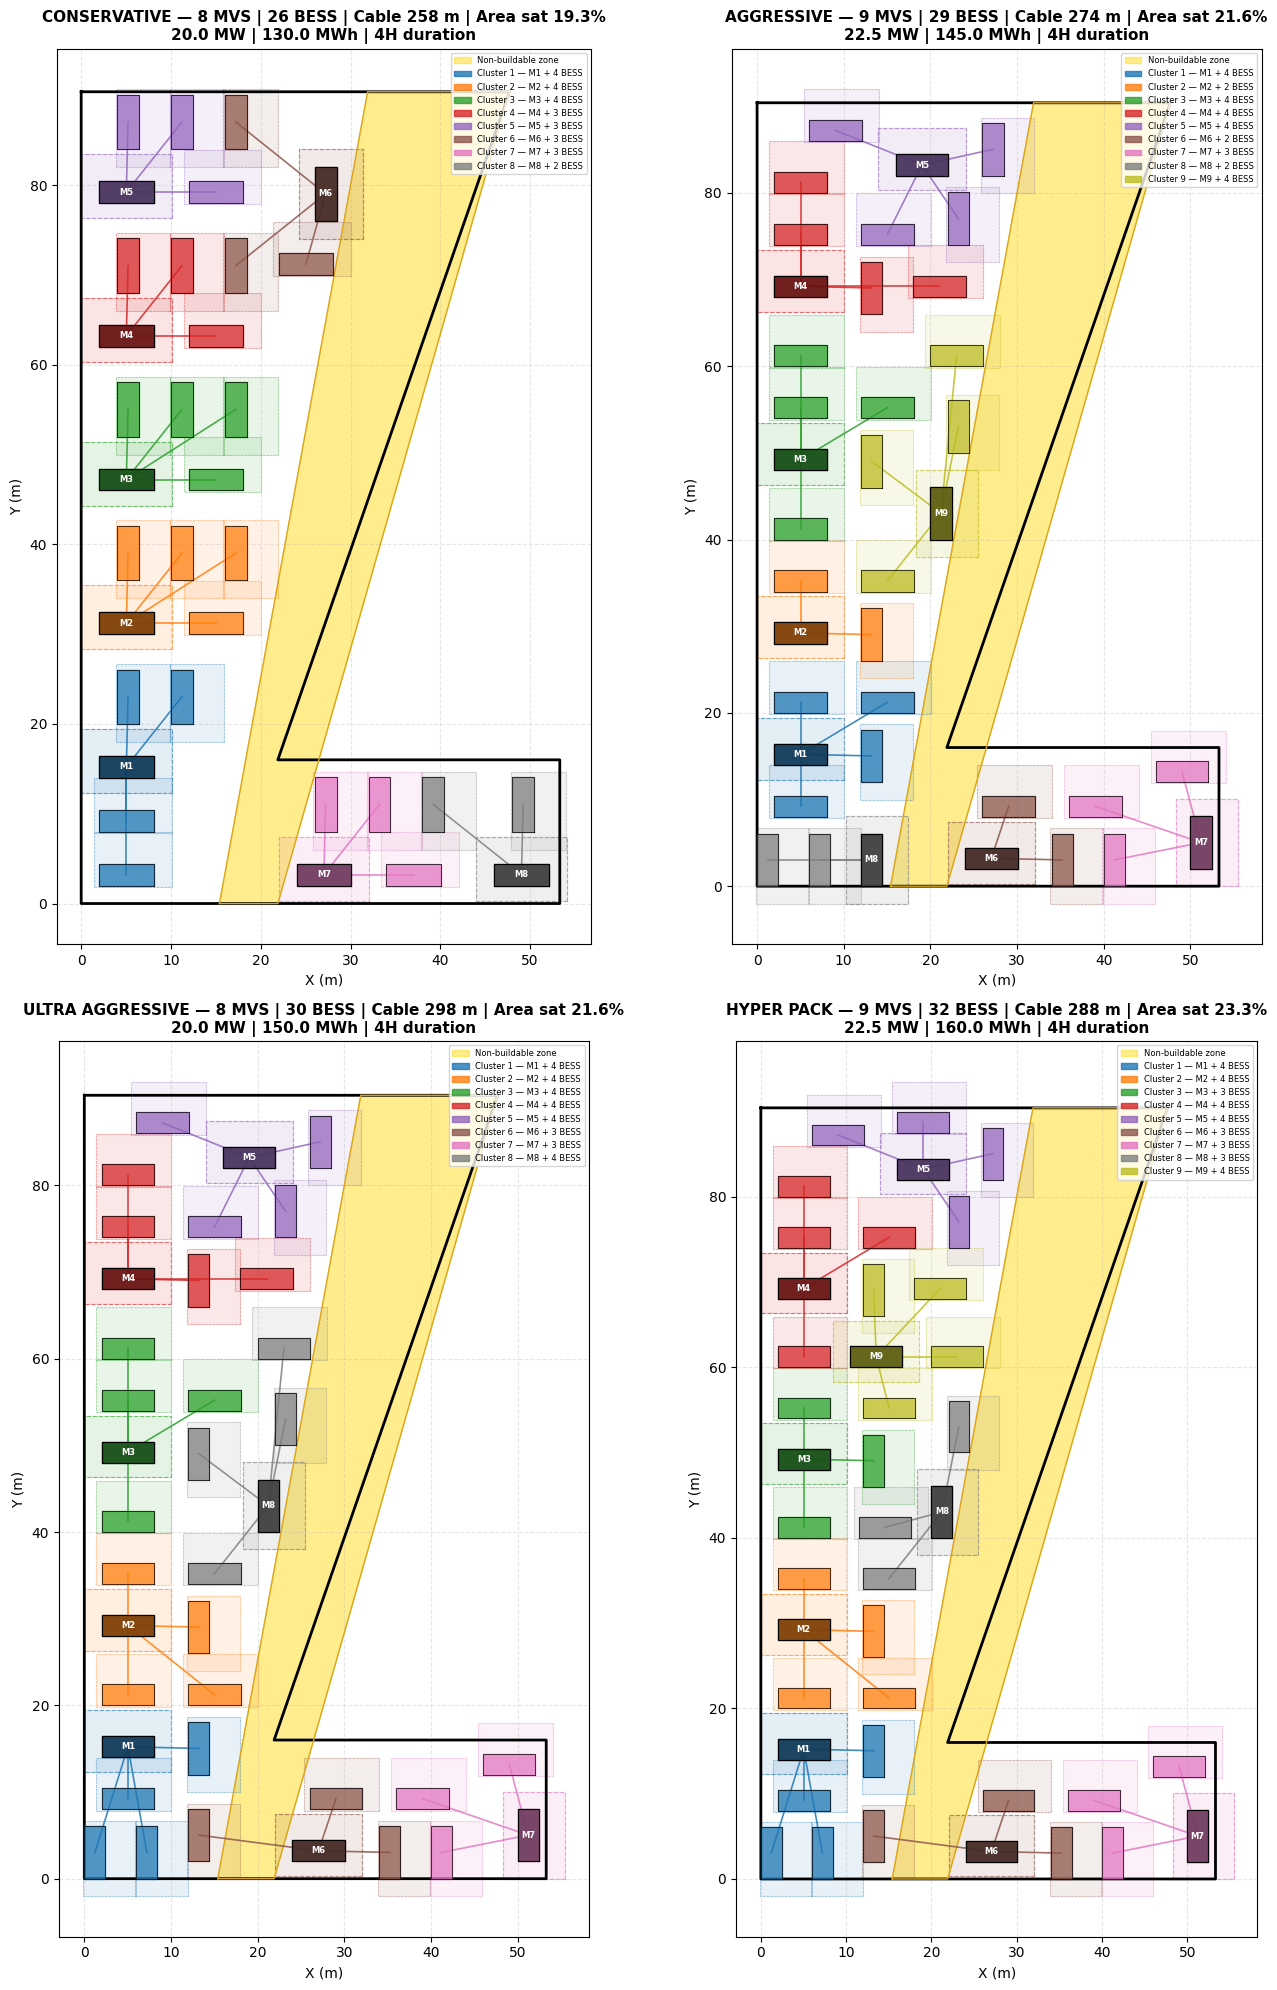

In [4]:
# 2x2 panel overview  (each title shows MW | MWh | duration)
plot_comparison(*scenarios, config=CONFIG)

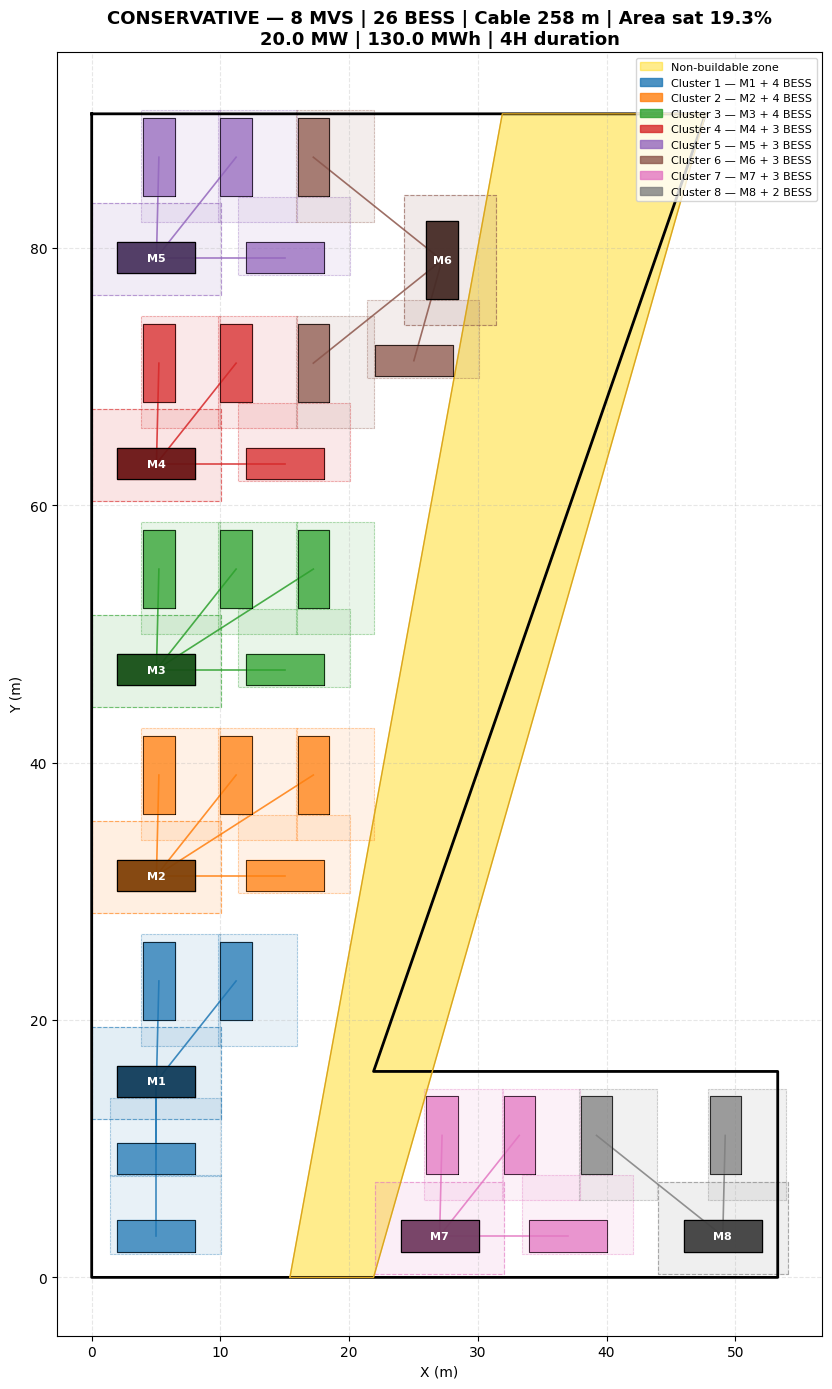

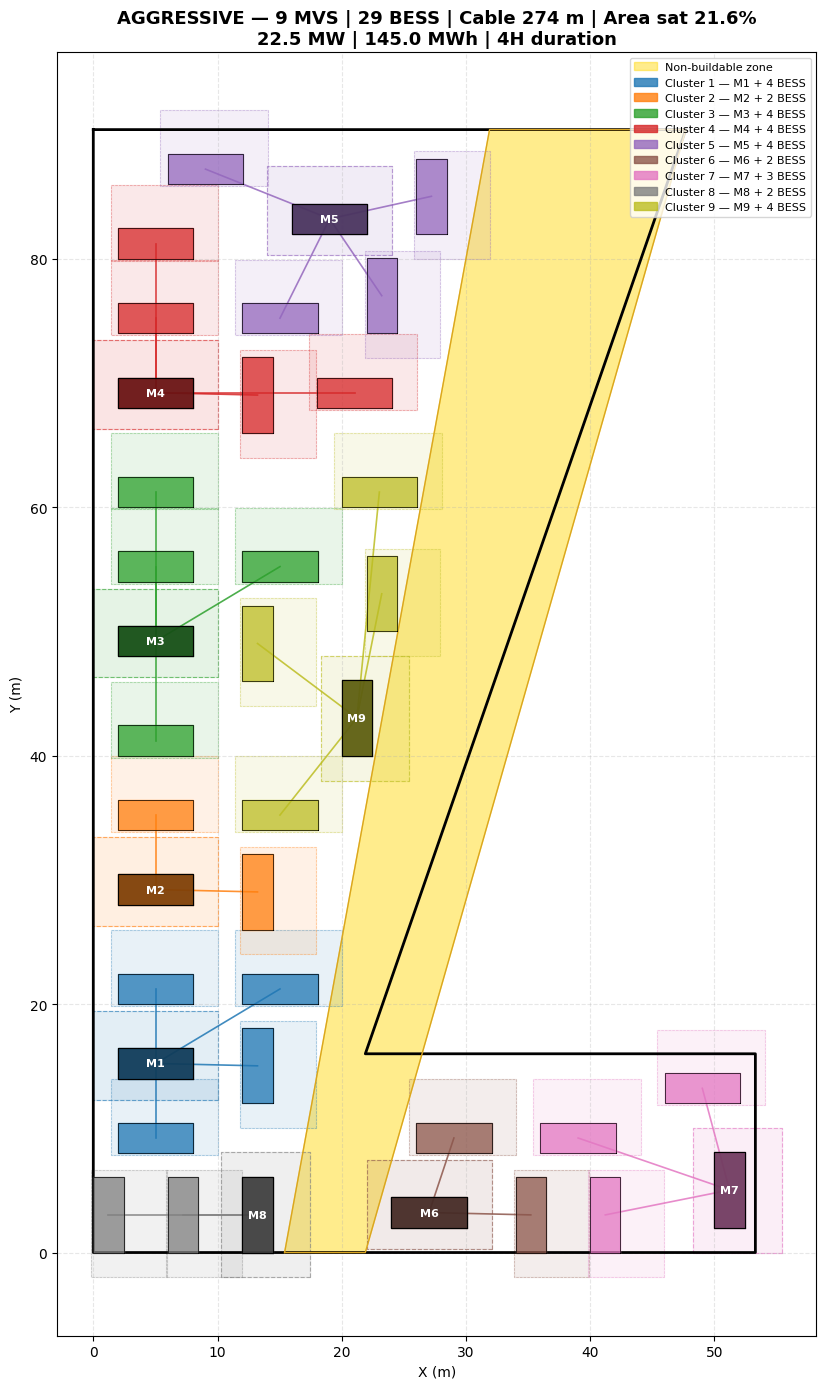

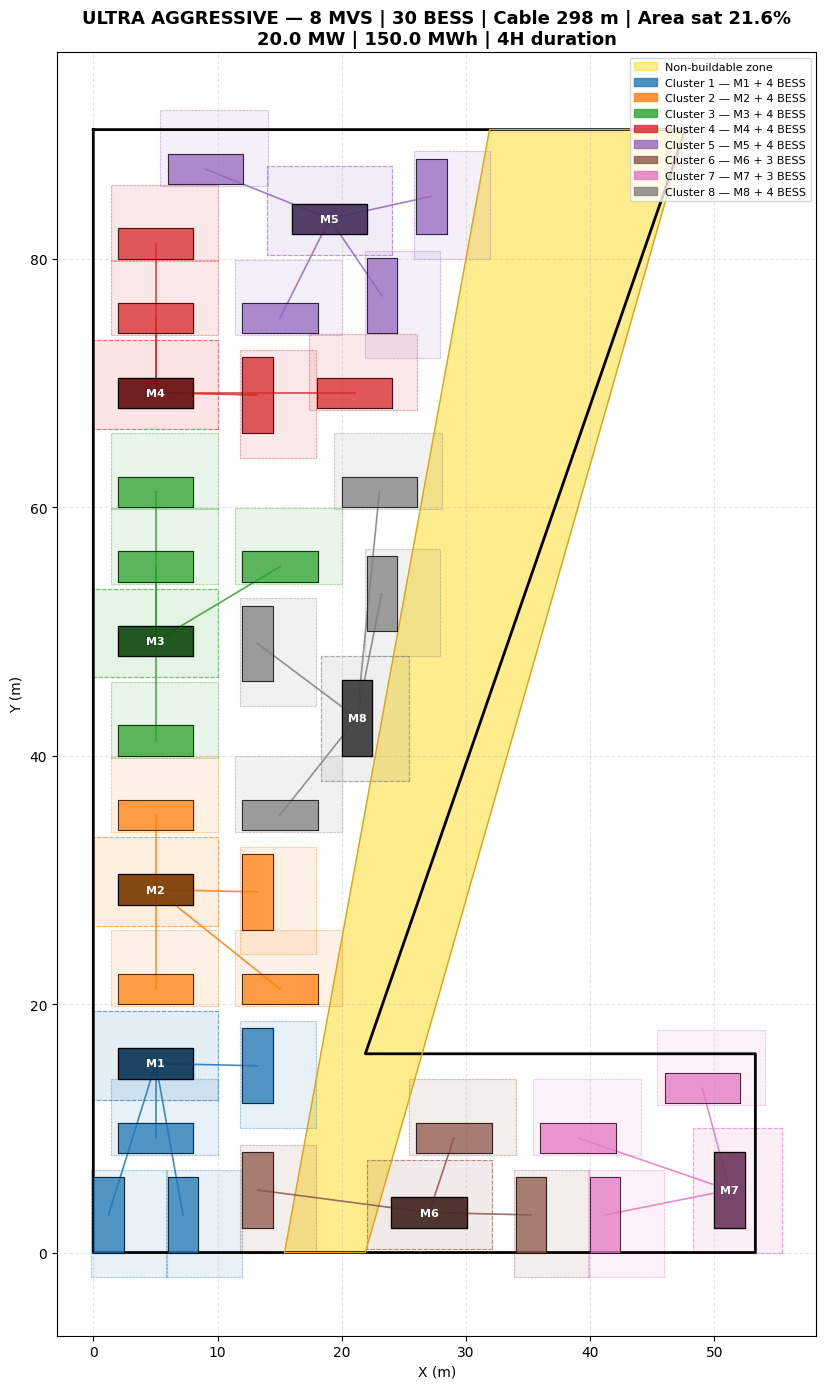

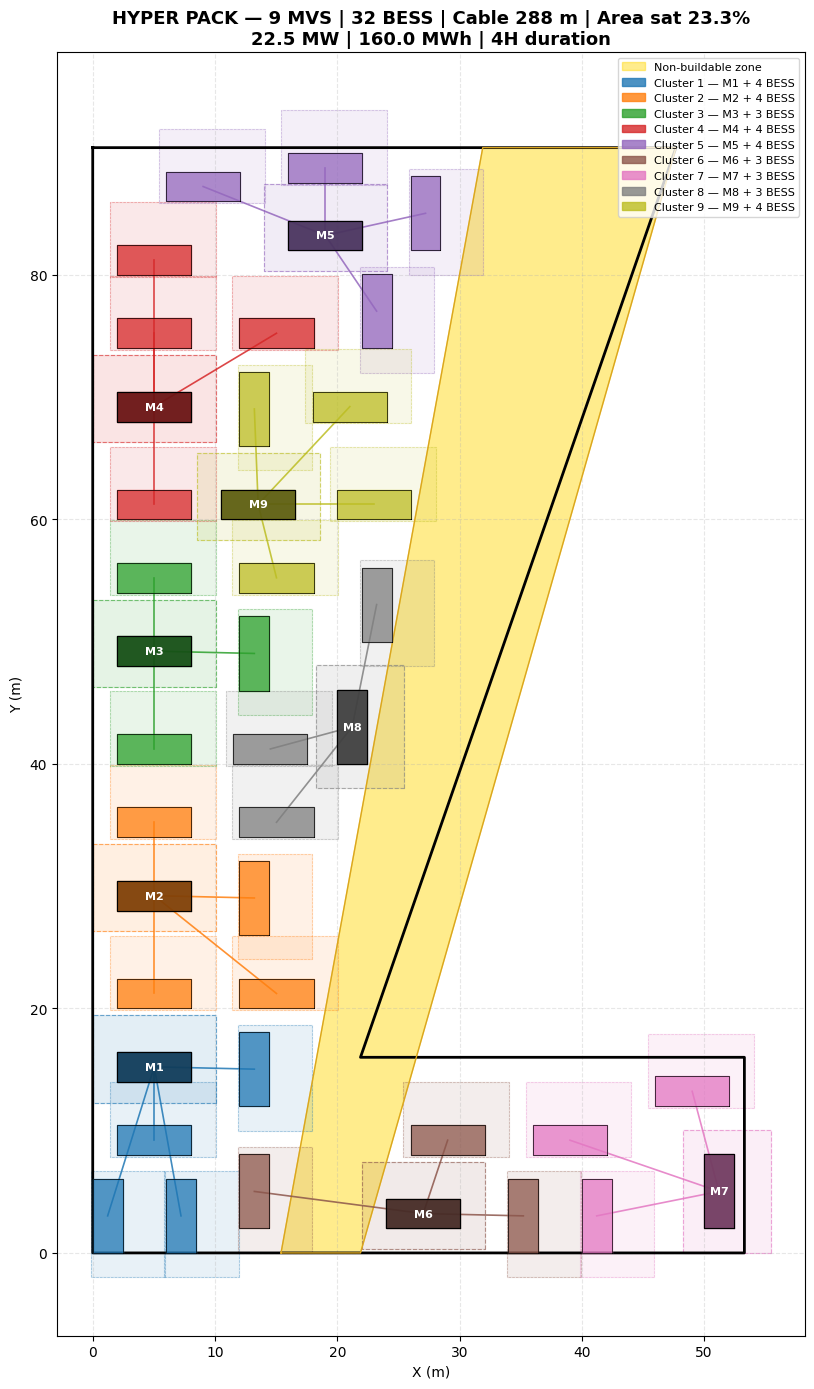

In [5]:
# Full-size standalone figures  (each title shows MW | MWh | duration)
plot_all_standalone(*scenarios, config=CONFIG)

In [6]:
# Optional: co-located / paired MVS scenario (shared-pad hubs)
CO_CONFIG = build_config(
    site_vertices=CONFIG['site_vertices'],
    non_buildable=[cable_corridor],
    restricted=[out_of_scope],
    bess_clearance={'front': 3.5, 'back': 0.15, 'left': 0.6, 'right': 2.0},
    mvs_clearance={'front': 3.0, 'back': 1.7,  'left': 2.0, 'right': 2.0},
    max_bess_per_mvs=4,
    bess_unit_mwh=BESS_UNIT_MWH,
    mvs_station_mw=MVS_STATION_MW,
    colocation={'enabled': True, 'group_size': 2, 'pad_gap': 0.5},
)
co_res = run_colocated_optimization(CO_CONFIG, mode='aggressive', verbose=True)
s = size_system(co_res['metrics']['bess_count'], co_res['metrics']['mvs_count'], BESS_UNIT_MWH, MVS_STATION_MW)
print(f"Co-located: {s['total_mw']:.1f} MW | {s['total_mwh']:.1f} MWh | {s['duration_label']}")


----- CO-LOCATED (AGGRESSIVE) -----
Hubs placed        : 4
MVS units placed   : 8
BESS units placed  : 27
Avg BESS / hub     : 6.8
Hub balance index  : 0.25
Foundation saving  : 50.0%
Total cable        : 261.1 m
Co-located: 20.0 MW | 135.0 MWh | 4H
